Q9 — Architecture du modèle
Le sujet suggère de partir d'un CNN simple comme baseline. C'est la bonne approche pour un hackathon : d'abord quelque chose qui marche, ensuite on améliore.

In [3]:
import torch
import torch.nn as nn

class RespiratoryCNN(nn.Module):
    def __init__(self, num_classes=5, in_channels=6):
        super().__init__()

        # Bloc 1 — détecte les patterns simples (bords, textures)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 128×259 → 64×129
            nn.Dropout2d(0.25)
        )

        # Bloc 2 — détecte les patterns plus complexes
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 64×129 → 32×64
            nn.Dropout2d(0.25)
        )

        # Bloc 3 — patterns de haut niveau
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),  # → 128×4×4 = 2048 features
            nn.Dropout2d(0.25)
        )

        # Classifieur final
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Vérifier les dimensions (6 canaux : mel, mfcc, centroid, bandwidth, zcr, chroma)
model = RespiratoryCNN(num_classes=5, in_channels=6)
dummy = torch.randn(8, 6, 128, 259)   # batch=8, canaux=6, H=128, W=259
out = model(dummy)
print(f"Sortie : {out.shape}")

Sortie : torch.Size([8, 5])


In [4]:
# Configuration GPU pour RTX 5070
import torch

# Détection GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()

# Hyperparamètres optimisés pour RTX 5070
BATCH_SIZE = 16  # RTX 5070 a ~16 GB → batch 16 ok
NUM_WORKERS = 0  # CPU workers pour data loading


Device utilisé : cuda
GPU : NVIDIA GeForce RTX 5070
VRAM disponible : 12.82 GB


Pour la présentation, justifie le choix CNN ainsi : les Mel-spectrogrammes sont des images 2D — les CNN sont conçus exactement pour ça, ils apprennent des filtres locaux (comme détecter une bande horizontale de wheezing) sans qu'on ait à les programmer manuellement.


Q10 — Split stratifié 70/15/15
Le split stratifié garantit que chaque classe (y compris Bronchial qui est rare) est représentée proportionnellement dans chaque split.

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.preprocessing import LabelEncoder

# Chargement des données depuis le fichier unifié
spectres = np.load("spectres.npy", allow_pickle=True).item()
mels = spectres["mel"]
labels = spectres["labels"]

assert len(mels) == len(labels), "Désalignement entre mels et labels dans spectres.npy"
print(f"Mels: {mels.shape} | Labels: {labels.shape}")

# Encodage des labels en entiers
le = LabelEncoder()
y_enc = le.fit_transform(labels)  # ex: asthma->0, bronchial->1...
print("Classes :", le.classes_)

# Split stratifié en 3 parties
indices = np.arange(len(mels))

# D'abord : 70% train / 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(sss1.split(indices, y_enc))

# Ensuite : 30% temp -> 15% val / 15% test
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(sss2.split(temp_idx, y_enc[temp_idx]))
val_idx = temp_idx[val_idx]
test_idx = temp_idx[test_idx]

print(f"Train : {len(train_idx)} | Val : {len(val_idx)} | Test : {len(test_idx)}")

# Vérifier la distribution dans chaque split
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    split_labels = y_enc[idx]
    unique, counts = np.unique(split_labels, return_counts=True)

    print(f"\n{name} :")
    for cls_id, cnt in zip(unique, counts):
        cls_name = le.classes_[cls_id]
        print(f"  {cls_name:12s} : {cnt:3d} ({cnt/len(idx)*100:.1f}%)")

Mels: (1211, 128, 259) | Labels: (1211,)
Classes : ['Bronchial' 'asthma' 'copd' 'healthy' 'pneumonia']
Train : 847 | Val : 182 | Test : 182

Train :
  Bronchial    :  73 (8.6%)
  asthma       : 201 (23.7%)
  copd         : 281 (33.2%)
  healthy      :  93 (11.0%)
  pneumonia    : 199 (23.5%)

Val :
  Bronchial    :  15 (8.2%)
  asthma       :  44 (24.2%)
  copd         :  60 (33.0%)
  healthy      :  20 (11.0%)
  pneumonia    :  43 (23.6%)

Test :
  Bronchial    :  16 (8.8%)
  asthma       :  43 (23.6%)
  copd         :  60 (33.0%)
  healthy      :  20 (11.0%)
  pneumonia    :  43 (23.6%)


In [ ]:
import torch
import torch.nn.functional as F
import cv2

class MultiSpectreDataset(Dataset):
    def __init__(self, spectres, labels, feature_keys=None):
        self.spectres = spectres
        self.y = torch.LongTensor(labels)
        self.feature_keys = feature_keys or ["mel", "mfcc", "centroid", "bandwidth", "zcr", "chroma"]
        self.num_channels = len(self.feature_keys)

    def __len__(self):
        return len(self.y)

    @staticmethod
    def _to_2d(arr):
        arr = np.asarray(arr, dtype=np.float32)
        if arr.ndim == 1:
            return arr[np.newaxis, :]
        return arr

    # @staticmethod
    # def _resize_2d(arr_2d, target_h, target_w):
    #     x = torch.tensor(arr_2d, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    #     x = F.interpolate(x, size=(target_h, target_w), mode="bilinear", align_corners=False)
    #     return x.squeeze(0).squeeze(0).numpy()
    

    @staticmethod
    def _resize_2d(arr_2d, target_h, target_w):
        return cv2.resize(arr_2d, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

    def __getitem__(self, idx):
        mel = self._to_2d(self.spectres["mel"][idx])
        target_h, target_w = mel.shape

        channels = []
        for key in self.feature_keys:
            feat = self._to_2d(self.spectres[key][idx])
            if feat.shape != (target_h, target_w):
                feat = self._resize_2d(feat, target_h, target_w)
            channels.append(feat)

        x = np.stack(channels, axis=0).astype(np.float32)  # (C, H, W)
        return torch.from_numpy(x), self.y[idx]

full_dataset = MultiSpectreDataset(spectres, y_enc)
print(f"Canaux utilisés : {full_dataset.feature_keys}")
print(f"Nombre de canaux : {full_dataset.num_channels}")

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(Subset(full_dataset, test_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Canaux utilisés : ['mel', 'mfcc', 'centroid', 'bandwidth', 'zcr', 'chroma']
Nombre de canaux : 6


In [12]:
import cv2

Boucle d'entraînement avec class weights

In [15]:
from sklearn.utils.class_weight import compute_class_weight

# Calcul des poids pour compenser le déséquilibre (Q2)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_enc),
    y=y_enc[train_idx]        # calculé sur le train seulement
)
weights_tensor = torch.FloatTensor(class_weights)

model = RespiratoryCNN(
    num_classes=len(le.classes_),
    in_channels=full_dataset.num_channels
).to(device)
weights_tensor = weights_tensor.to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item()
            correct += (out.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Entraînement
EPOCHS = 50
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Train loss {train_loss:.3f} acc {train_acc:.3f} | "
            f"Val loss {val_loss:.3f} acc {val_acc:.3f}"
        )

# Sauvegarder le modèle

torch.save(model.state_dict(), "cnn_respiratory.pth")
# Sauvegarder le modèletorch.save(model.state_dict(), "cnn_respiratory.pth")

Epoch   5 | Train loss 1.313 acc 0.464 | Val loss 1.130 acc 0.577
Epoch  10 | Train loss 1.207 acc 0.512 | Val loss 1.025 acc 0.588
Epoch  15 | Train loss 1.096 acc 0.555 | Val loss 0.929 acc 0.637
Epoch  20 | Train loss 1.049 acc 0.588 | Val loss 0.886 acc 0.643
Epoch  25 | Train loss 0.993 acc 0.609 | Val loss 0.824 acc 0.665
Epoch  30 | Train loss 0.983 acc 0.603 | Val loss 0.874 acc 0.626
Epoch  35 | Train loss 0.955 acc 0.630 | Val loss 0.802 acc 0.676
Epoch  40 | Train loss 0.902 acc 0.664 | Val loss 0.769 acc 0.681
Epoch  45 | Train loss 0.913 acc 0.641 | Val loss 0.774 acc 0.703
Epoch  50 | Train loss 0.865 acc 0.695 | Val loss 0.721 acc 0.687


Q11 — Métriques adaptées au contexte médical
L'accuracy seule ne suffit pas — un modèle qui prédit toujours "COPD" (classe majoritaire) aurait ~30% d'accuracy sans rien apprendre.

              precision    recall  f1-score   support

   Bronchial       0.56      0.31      0.40        16
      asthma       0.82      0.95      0.88        43
        copd       0.80      0.65      0.72        60
     healthy       0.61      1.00      0.75        20
   pneumonia       0.76      0.72      0.74        43

    accuracy                           0.75       182
   macro avg       0.71      0.73      0.70       182
weighted avg       0.75      0.75      0.74       182

Macro F1-score : 0.698
Macro AUC-ROC  : 0.950


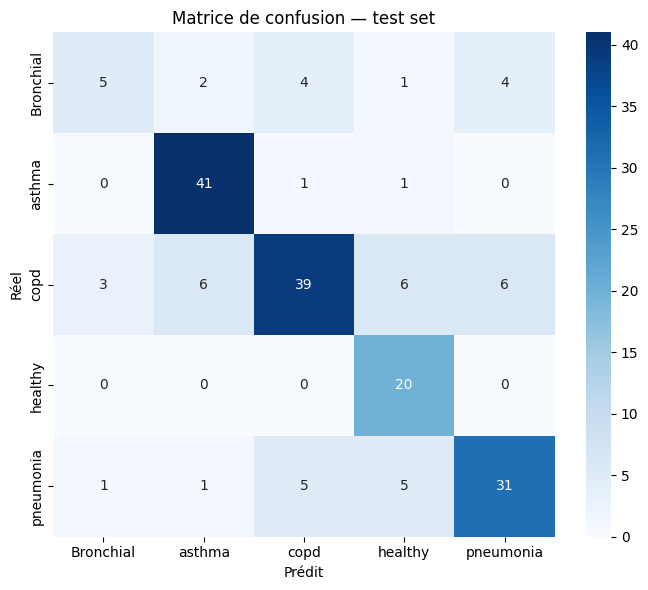

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_probs, all_true = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        out   = model(X_batch)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).numpy())
        all_probs.extend(probs.numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

# Rapport complet
print(classification_report(all_true, all_preds,
                              target_names=le.classes_))

# Macro F1 — pondère également chaque classe
f1_macro = f1_score(all_true, all_preds, average='macro')
print(f"Macro F1-score : {f1_macro:.3f}")

# AUC-ROC multiclasse
auc = roc_auc_score(all_true, all_probs, multi_class='ovr', average='macro')
print(f"Macro AUC-ROC  : {auc:.3f}")

# Matrice de confusion
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Matrice de confusion — test set")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()

Pour la présentation, insiste sur ce point clé : en médecine, un faux négatif (manquer une pneumonie) est bien plus grave qu'un faux positif. C'est pourquoi on surveille le recall par classe en priorité sur l'accuracy globale.

Q12 — Data augmentation avec SpecAugment
SpecAugment s'applique directement sur les Mel-spectrogrammes pendant l'entraînement — pas besoin de régénérer les fichiers.

In [ ]:
import torch
import random

def spec_augment(mel, freq_mask_param=20, time_mask_param=40, num_masks=2):
    """
    Applique SpecAugment sur un tensor Mel (H, W)
    freq_mask_param : largeur max du masque fréquentiel (en bandes Mel)
    time_mask_param : largeur max du masque temporel (en frames)
    num_masks       : nombre de masques appliqués par axe
    """
    mel = mel.clone()
    H, W = mel.shape

    # Masques fréquentiels — cache des bandes horizontales
    for _ in range(num_masks):
        f = random.randint(0, freq_mask_param)
        f0 = random.randint(0, max(0, H - f))
        mel[f0:f0 + f, :] = 0.0

    # Masques temporels — cache des bandes verticales
    for _ in range(num_masks):
        t = random.randint(0, time_mask_param)
        t0 = random.randint(0, max(0, W - t))
        mel[:, t0:t0 + t] = 0.0

    return mel

# Dataset multi-spectres avec augmentation appliquée sur le canal Mel (canal 0)
class MultiSpectreDatasetAug(MultiSpectreDataset):
    def __init__(self, spectres, labels, feature_keys=None, augment=False):
        super().__init__(spectres, labels, feature_keys=feature_keys)
        self.augment = augment

    def __getitem__(self, idx):
        x, y = super().__getitem__(idx)
        if self.augment:
            x = x.clone()
            x[0] = spec_augment(x[0])
        return x, y

# Remplacer le train_loader par la version augmentée
feature_keys = full_dataset.feature_keys
train_spectres = {k: np.asarray(v)[train_idx] for k, v in spectres.items() if k != "labels"}
train_dataset_aug = MultiSpectreDatasetAug(
    train_spectres,
    y_enc[train_idx],
    feature_keys=feature_keys,
    augment=True
)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)

print(f"Train loader augmenté prêt avec {train_dataset_aug.num_channels} canaux")

Train loader augmenté prêt avec 6 canaux


In [ ]:
# Fine-tuning après activation de SpecAugment
# Important: ce bloc continue l'entraînement du modèle déjà appris ci-dessus.

EPOCHS_AUG = 15
best_val_loss = float("inf")

for epoch in range(EPOCHS_AUG):
    # On entraîne avec le loader augmenté
    train_loss, train_acc = train_epoch(model, train_loader_aug, criterion, optimizer)

    # Validation sans augmentation
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "cnn_respiratory_aug_best.pth")

    print(
        f"[AUG] Epoch {epoch+1:2d}/{EPOCHS_AUG} | "
        f"Train loss {train_loss:.3f} acc {train_acc:.3f} | "
        f"Val loss {val_loss:.3f} acc {val_acc:.3f}"
    )

print("Fine-tuning SpecAugment terminé.")
print("Meilleur modèle sauvegardé: cnn_respiratory_aug_best.pth")

[AUG] Epoch  1/15 | Train loss 0.959 acc 0.653 | Val loss 0.783 acc 0.698
[AUG] Epoch  2/15 | Train loss 1.018 acc 0.630 | Val loss 0.804 acc 0.665
[AUG] Epoch  3/15 | Train loss 0.923 acc 0.636 | Val loss 0.764 acc 0.709
[AUG] Epoch  4/15 | Train loss 0.910 acc 0.645 | Val loss 0.801 acc 0.676
[AUG] Epoch  5/15 | Train loss 0.897 acc 0.664 | Val loss 0.741 acc 0.681
[AUG] Epoch  6/15 | Train loss 0.923 acc 0.647 | Val loss 0.732 acc 0.687
[AUG] Epoch  7/15 | Train loss 0.842 acc 0.674 | Val loss 0.718 acc 0.692
[AUG] Epoch  8/15 | Train loss 0.902 acc 0.655 | Val loss 0.749 acc 0.703
[AUG] Epoch  9/15 | Train loss 0.866 acc 0.672 | Val loss 0.689 acc 0.720
[AUG] Epoch 10/15 | Train loss 0.814 acc 0.677 | Val loss 0.677 acc 0.725
[AUG] Epoch 11/15 | Train loss 0.769 acc 0.695 | Val loss 0.695 acc 0.725
[AUG] Epoch 12/15 | Train loss 0.864 acc 0.667 | Val loss 0.720 acc 0.709
[AUG] Epoch 13/15 | Train loss 0.839 acc 0.686 | Val loss 0.709 acc 0.703
[AUG] Epoch 14/15 | Train loss 0.830 a

C:\Users\paulo\AppData\Local\Temp\ipykernel_13072\313877078.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_aug.load_state_dict(torch.load("cnn_respiratory_aug_be

RÉSULTATS MODÈLE AFTER SpecAugment

Classification Report:
              precision    recall  f1-score   support

   Bronchial       0.57      0.75      0.65        16
      asthma       0.80      0.91      0.85        43
        copd       0.86      0.63      0.73        60
     healthy       0.49      0.95      0.64        20
   pneumonia       0.90      0.60      0.72        43

    accuracy                           0.74       182
   macro avg       0.72      0.77      0.72       182
weighted avg       0.79      0.74      0.74       182


✓ Macro F1-score (SpecAugment) : 0.7187
✓ F1-score précédent (baseline) : 0.6980
✓ Amélioration                   : +0.0207

✓ Macro AUC-ROC (SpecAugment)  : 0.9436
✓ AUC-ROC précédent (baseline) : 0.9502
✓ Amélioration                 : +-0.0066


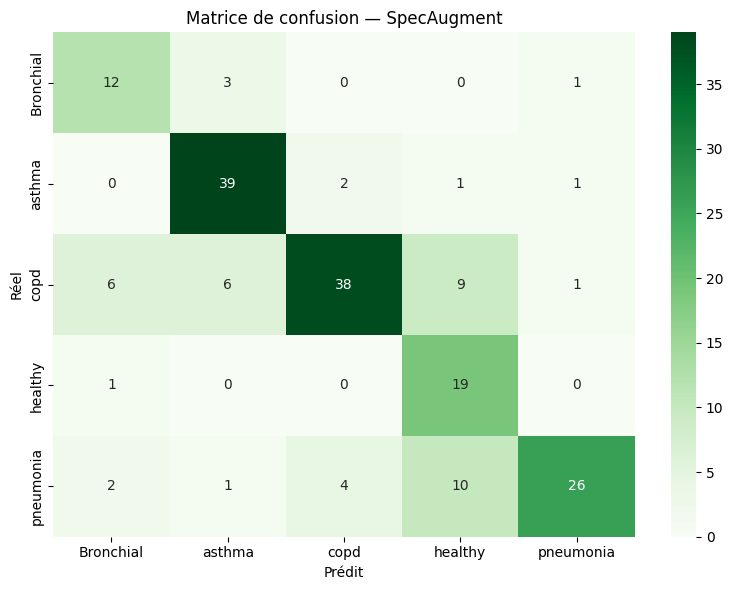


✓ Résultats sauvegardés dans confusion_matrix_aug.png


In [ ]:
# Évaluation du modèle augmenté sur le test set
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le meilleur modèle augmenté
model_aug = RespiratoryCNN(
    num_classes=len(le.classes_), in_channels=full_dataset.num_channels
).to(device)
model_aug.load_state_dict(torch.load("cnn_respiratory_aug_best.pth"))

# Évaluation sur test set
model_aug.eval()
all_preds_aug, all_probs_aug, all_true_aug = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        out = model_aug(X_batch)
        probs = torch.softmax(out, dim=1)
        all_preds_aug.extend(out.argmax(1).cpu().numpy())
        all_probs_aug.extend(probs.cpu().numpy())
        all_true_aug.extend(y_batch.numpy())

all_preds_aug = np.array(all_preds_aug)
all_probs_aug = np.array(all_probs_aug)
all_true_aug = np.array(all_true_aug)

# Calcul des métriques
print("=" * 70)
print("RÉSULTATS MODÈLE AFTER SpecAugment")
print("=" * 70)

print("\nClassification Report:")
print(
    classification_report(
        all_true_aug, all_preds_aug, target_names=le.classes_
    )
)

f1_macro_aug = f1_score(all_true_aug, all_preds_aug, average="macro")
print(f"\n✓ Macro F1-score (SpecAugment) : {f1_macro_aug:.4f}")
print(f"✓ F1-score précédent (baseline) : {f1_macro:.4f}")
print(f"✓ Amélioration                   : +{f1_macro_aug - f1_macro:.4f}")

auc_aug = roc_auc_score(
    all_true_aug, all_probs_aug, multi_class="ovr", average="macro"
)
print(f"\n✓ Macro AUC-ROC (SpecAugment)  : {auc_aug:.4f}")
print(f"✓ AUC-ROC précédent (baseline) : {auc:.4f}")
print(f"✓ Amélioration                 : +{auc_aug - auc:.4f}")

# Matrice de confusion
cm_aug = confusion_matrix(all_true_aug, all_preds_aug)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_aug,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("Matrice de confusion — SpecAugment")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.tight_layout()
plt.show()

print("\n✓ Résultats sauvegardés dans confusion_matrix_aug.png")

In [ ]:
# Export ONNX
from pathlib import Path
import numpy as np
import torch

onnx_path = Path("cnn_respiratory.onnx")
checkpoint_candidates = [
    "cnn_respiratory_aug_best.pth",
    "cnn_respiratory.pth",
]

export_model = RespiratoryCNN(
    num_classes=len(le.classes_),
    in_channels=full_dataset.num_channels,
)
loaded_from = None

for ckpt in checkpoint_candidates:
    ckpt_path = Path(ckpt)
    if ckpt_path.exists():
        state_dict = torch.load(str(ckpt_path), map_location="cpu")
        export_model.load_state_dict(state_dict)
        loaded_from = str(ckpt_path)
        break

if loaded_from is None:
    export_model.load_state_dict(model.state_dict())
    loaded_from = "model_en_memoire"

export_model.eval().cpu()

sample_mel = np.asarray(spectres["mel"][0])
if sample_mel.ndim == 1:
    input_h, input_w = 1, sample_mel.shape[0]
else:
    input_h, input_w = sample_mel.shape[-2], sample_mel.shape[-1]

dummy_input = torch.randn(
    1,
    full_dataset.num_channels,
    input_h,
    input_w,
    dtype=torch.float32,
 )

torch.onnx.export(
    export_model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
)

print(f"Modele source: {loaded_from}")
print(f"Export ONNX termine: {onnx_path.resolve()}")
print(f"Taille entree ONNX: (batch, {full_dataset.num_channels}, {input_h}, {input_w})")